# Smart Postal ML System Training
## 2-Model Architecture for Intelligent Mail Processing

**Objective**: Train ML models to:
1. Classify mail priority (urgent vs regular)
2. Optimize delivery routes with dynamic rerouting

In [138]:
# SECTION 0: ENVIRONMENT SETUP & IMPORTS
# This cell installs all required packages automatically

print("=" * 80)
print("SMART POSTAL ML SYSTEM - INITIALIZING")
print("=" * 80)

import subprocess
import sys

def install_package(package):
    """Install package if not already installed"""
    try:
        __import__(package.split('[')[0].replace('-', '_'))
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Install required packages
packages = ['pandas', 'numpy', 'scikit-learn', 'xgboost', 'matplotlib', 'seaborn']
for pkg in packages:
    install_package(pkg)

print("\n✅ All packages installed successfully!")

SMART POSTAL ML SYSTEM - INITIALIZING
Installing scikit-learn...

✅ All packages installed successfully!


In [139]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import pickle
import json
import random
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
from math import radians, sin, cos, sqrt, atan2

warnings.filterwarnings('ignore')

# Machine Learning imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✅ All imports successful!")
print(f"📌 Random seed: {RANDOM_SEED}")

✅ All imports successful!
📌 Random seed: 42


In [140]:
class PriorityClassificationModel:
    """
    MODEL 1: Priority Classification using XGBoost
    
    Classifies mail items as urgent or regular based on attributes
    using sophisticated feature engineering and class imbalance handling.
    """
    
    def __init__(self, random_state: int = 42):
        """Initialize the priority classification model"""
        self.random_state = random_state
        self.model = None
        self.encoders = {}
        self.scaler = StandardScaler()
        self.feature_names = []
        self.is_trained = False
        
        # Define feature spaces (Sri Lankan postal context)
        self.MAIL_TYPES = [
            'Court Notice', 'Legal Document', 'Registered Letter', 'Speed Post',
            'Express Mail', 'Tax Document', 'Government Letter', 'Bank Document',
            'Medical Report', 'Insurance Document', 'Certificate', 'Parcel',
            'Standard Letter', 'Magazine', 'Bill', 'Advertisement'
        ]
        
        self.SENDER_TYPES = [
            'Court', 'Law Firm', 'Government Office', 'Tax Office', 'Bank',
            'Hospital', 'Insurance Company', 'Educational Institute',
            'Business', 'Individual', 'NGO'
        ]
        
        self.RECIPIENT_TYPES = [
            'Individual', 'Business', 'Government Office', 'Law Firm',
            'Educational Institute', 'Hospital', 'Bank', 'Insurance Company'
        ]
        
        self.TIME_SLOTS = ['08:00', '09:30', '11:00', '13:00', '14:30', '16:00']
        self.DAYS_OF_WEEK = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    
    def generate_training_data(self, n_samples: int = 25000) -> pd.DataFrame:
        """
        Generate synthetic training data with realistic patterns
        
        Business Rules for Priority Assignment:
        ---------------------------------------
        1. Legal/Court documents → High priority (Score: +4)
        2. Government + Tax documents → High priority (Score: +3)
        3. Registered/Express mail → High priority (Score: +4)
        4. Medical reports from hospitals → Medium priority (Score: +2)
        5. Early morning delivery → Boost priority (Score: +1)
        6. Monday/Tuesday delivery → Slight boost (Score: +1)
        7. Priority sender + Individual recipient → Boost (Score: +2)
        
        Threshold: Score ≥ 5 → URGENT
        
        Parameters:
        -----------
        n_samples : int
            Number of training samples to generate
            
        Returns:
        --------
        pd.DataFrame : Training dataset with labels
        """
        
        print(f"\n📊 Generating {n_samples:,} training samples...")
        
        records = []
        
        for i in range(n_samples):
            # Random selection
            mail_type = random.choice(self.MAIL_TYPES)
            sender_type = random.choice(self.SENDER_TYPES)
            recipient_type = random.choice(self.RECIPIENT_TYPES)
            time_received = random.choice(self.TIME_SLOTS)
            day_of_week = random.choice(self.DAYS_OF_WEEK)
            
            # Urgency scoring logic (0-10 scale)
            urgency_score = 0
            
            # Rule 1: High priority mail types
            if mail_type in ['Court Notice', 'Legal Document', 'Registered Letter', 
                           'Speed Post', 'Express Mail', 'Tax Document', 'Certificate']:
                urgency_score += 4
            
            # Rule 2: High priority senders
            if sender_type in ['Court', 'Law Firm', 'Government Office', 'Tax Office']:
                urgency_score += 3
            
            # Rule 3: Specific combinations
            if mail_type == 'Medical Report' and sender_type == 'Hospital':
                urgency_score += 2
            if mail_type in ['Bank Document', 'Insurance Document'] and recipient_type in ['Business', 'Individual']:
                urgency_score += 1
            
            # Rule 4: Time sensitivity
            if time_received in ['08:00', '09:30']:
                urgency_score += 1
            
            # Rule 5: Day sensitivity
            if day_of_week in ['Monday', 'Tuesday']:
                urgency_score += 1
            
            # Rule 6: Critical combinations
            if sender_type in ['Court', 'Law Firm'] and recipient_type == 'Individual':
                urgency_score += 2
            
            # Rule 7: Express combinations
            if mail_type in ['Speed Post', 'Express Mail'] and time_received in ['08:00', '09:30']:
                urgency_score += 1
            
            # Determine urgency (threshold: 5)
            is_urgent = urgency_score >= 5
            
            # Add 2% noise for realism
            if random.random() < 0.02:
                is_urgent = not is_urgent
            
            records.append({
                'mail_id': f'MAIL{i+1:06d}',
                'mail_type': mail_type,
                'sender_type': sender_type,
                'recipient_type': recipient_type,
                'time_received': time_received,
                'day_of_week': day_of_week,
                'urgency_score': urgency_score,
                'priority': 'urgent' if is_urgent else 'regular'
            })
        
        df = pd.DataFrame(records)
        
        # Statistics
        class_counts = df['priority'].value_counts()
        print(f"✅ Dataset created successfully")
        print(f"\n   Class distribution:")
        for label, count in class_counts.items():
            print(f"   • {label}: {count:,} ({count/len(df)*100:.1f}%)")
        
        return df
    
    def preprocess_features(self, df: pd.DataFrame, fit: bool = True) -> np.ndarray:
        """
        Comprehensive feature engineering pipeline
        
        Steps:
        ------
        1. Encode categorical features using LabelEncoder
        2. Create temporal features (time category)
        3. Create binary indicator features
        4. Create interaction features
        5. Scale all features using StandardScaler
        
        Parameters:
        -----------
        df : pd.DataFrame
            Input dataframe with raw features
        fit : bool
            If True, fit encoders and scaler; if False, transform only
            
        Returns:
        --------
        np.ndarray : Processed feature matrix
        """
        
        df = df.copy()
        
        # 1. Encode categorical features
        categorical_features = ['mail_type', 'sender_type', 'recipient_type', 
                               'time_received', 'day_of_week']
        
        for feature in categorical_features:
            if fit:
                self.encoders[feature] = LabelEncoder()
                df[f'{feature}_encoded'] = self.encoders[feature].fit_transform(df[feature])
            else:
                df[f'{feature}_encoded'] = self.encoders[feature].transform(df[feature])
        
        # 2. Temporal features
        time_to_category = {
            '08:00': 0, '09:30': 0,  # Early morning
            '11:00': 1, '13:00': 1,  # Mid-day
            '14:30': 2, '16:00': 2   # Afternoon
        }
        df['time_category'] = df['time_received'].map(time_to_category)
        
        # 3. Binary indicators
        df['is_priority_sender'] = df['sender_type'].isin(
            ['Court', 'Law Firm', 'Government Office', 'Tax Office']
        ).astype(int)
        
        df['is_priority_mail'] = df['mail_type'].isin(
            ['Court Notice', 'Legal Document', 'Registered Letter', 
             'Speed Post', 'Express Mail', 'Tax Document', 'Certificate']
        ).astype(int)
        
        df['is_early_week'] = df['day_of_week'].isin(['Monday', 'Tuesday']).astype(int)
        df['is_morning'] = df['time_received'].isin(['08:00', '09:30']).astype(int)
        
        # 4. Interaction features
        df['priority_sender_mail'] = df['is_priority_sender'] * df['is_priority_mail']
        df['morning_priority'] = df['is_morning'] * df['is_priority_mail']
        df['early_week_priority'] = df['is_early_week'] * df['is_priority_mail']
        df['morning_early_week'] = df['is_morning'] * df['is_early_week']
        
        # 5. Select feature columns
        self.feature_names = [
            'mail_type_encoded', 'sender_type_encoded', 'recipient_type_encoded',
            'time_received_encoded', 'day_of_week_encoded', 'time_category',
            'is_priority_sender', 'is_priority_mail', 'is_early_week', 'is_morning',
            'priority_sender_mail', 'morning_priority', 'early_week_priority',
            'morning_early_week'
        ]
        
        X = df[self.feature_names].values
        
        # 6. Scale features
        if fit:
            X = self.scaler.fit_transform(X)
        else:
            X = self.scaler.transform(X)
        
        return X
    
    def train(self, df: pd.DataFrame, test_size: float = 0.2, 
             tune_hyperparameters: bool = False) -> Dict:
        """
        Train the priority classification model
        
        Parameters:
        -----------
        df : pd.DataFrame
            Training data with labels
        test_size : float
            Proportion of data for testing (default: 0.2)
        tune_hyperparameters : bool
            If True, perform GridSearchCV for hyperparameter tuning
            
        Returns:
        --------
        dict : Training results including metrics and evaluation data
        """
        
        print(f"\n🔧 Training Priority Classification Model...")
        print(f"   Training samples: {int(len(df) * (1-test_size)):,}")
        print(f"   Test samples: {int(len(df) * test_size):,}")
        
        # Preprocess features
        X = self.preprocess_features(df, fit=True)
        
        # Encode target
        le_target = LabelEncoder()
        y = le_target.fit_transform(df['priority'])
        self.encoders['target'] = le_target
        
        # Split data with stratification
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=self.random_state, stratify=y
        )
        
        # Calculate class weights
        class_weights = compute_class_weight(
            'balanced', 
            classes=np.unique(y_train), 
            y=y_train
        )
        scale_pos_weight = class_weights[1] / class_weights[0]
        
        print(f"   Class weight ratio: {scale_pos_weight:.2f} (favoring urgent class)")
        
        # Model training
        if tune_hyperparameters:
            print(f"\n   🔍 Tuning hyperparameters with GridSearchCV...")
            
            param_grid = {
                'n_estimators': [200, 300, 400],
                'max_depth': [6, 8, 10],
                'learning_rate': [0.05, 0.1, 0.15],
                'subsample': [0.8, 0.9],
                'colsample_bytree': [0.8, 0.9]
            }
            
            xgb_base = xgb.XGBClassifier(
                scale_pos_weight=scale_pos_weight,
                random_state=self.random_state,
                eval_metric='logloss',
                use_label_encoder=False
            )
            
            grid_search = GridSearchCV(
                xgb_base,
                param_grid,
                cv=5,
                scoring='recall',
                n_jobs=-1,
                verbose=1
            )
            
            grid_search.fit(X_train, y_train)
            self.model = grid_search.best_estimator_
            
            print(f"\n   ✅ Best parameters:")
            for param, value in grid_search.best_params_.items():
                print(f"      • {param}: {value}")
        
        else:
            # Use optimized default parameters
            self.model = xgb.XGBClassifier(
                n_estimators=300,
                max_depth=8,
                learning_rate=0.1,
                subsample=0.9,
                colsample_bytree=0.9,
                scale_pos_weight=scale_pos_weight,
                random_state=self.random_state,
                eval_metric='logloss',
                use_label_encoder=False
            )
            
            print(f"\n   🎯 Training with optimized parameters...")
            self.model.fit(X_train, y_train)
        
        self.is_trained = True
        
        # Predictions
        y_pred = self.model.predict(X_test)
        y_pred_proba = self.model.predict_proba(X_test)
        
        # Calculate metrics
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1_score': f1_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_pred_proba[:, 1])
        }
        
        # Cross-validation
        cv_scores_recall = cross_val_score(
            self.model, X_train, y_train, cv=5, scoring='recall'
        )
        cv_scores_precision = cross_val_score(
            self.model, X_train, y_train, cv=5, scoring='precision'
        )
        
        metrics['cv_recall_mean'] = cv_scores_recall.mean()
        metrics['cv_recall_std'] = cv_scores_recall.std()
        metrics['cv_precision_mean'] = cv_scores_precision.mean()
        metrics['cv_precision_std'] = cv_scores_precision.std()
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        # Feature importance
        feature_importance = pd.DataFrame({
            'feature': self.feature_names,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False)
        
        # Print results
        print(f"\n{'=' * 70}")
        print("📊 MODEL 1: PERFORMANCE METRICS")
        print(f"{'=' * 70}")
        print(f"   Accuracy:  {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
        print(f"   Precision: {metrics['precision']:.4f} ({metrics['precision']*100:.2f}%)")
        
        recall_status = "✅ TARGET MET" if metrics['recall'] >= 0.95 else "⚠️  Below target"
        print(f"   Recall:    {metrics['recall']:.4f} ({metrics['recall']*100:.2f}%) {recall_status}")
        print(f"   F1-Score:  {metrics['f1_score']:.4f}")
        print(f"   ROC-AUC:   {metrics['roc_auc']:.4f}")
        
        print(f"\n   Cross-Validation (5-fold):")
        print(f"   Recall:    {metrics['cv_recall_mean']:.4f} (±{metrics['cv_recall_std']:.4f})")
        print(f"   Precision: {metrics['cv_precision_mean']:.4f} (±{metrics['cv_precision_std']:.4f})")
        
        print(f"\n   Confusion Matrix:")
        print(f"                    Predicted")
        print(f"                Regular  Urgent")
        print(f"   Actual Regular  {cm[0,0]:5d}   {cm[0,1]:5d}")
        print(f"          Urgent   {cm[1,0]:5d}   {cm[1,1]:5d}")
        
        print(f"\n   Top 5 Important Features:")
        for idx, row in feature_importance.head(5).iterrows():
            print(f"   • {row['feature']:25s}: {row['importance']:.4f}")
        
        return {
            'model': self.model,
            'metrics': metrics,
            'confusion_matrix': cm,
            'feature_importance': feature_importance,
            'X_test': X_test,
            'y_test': y_test,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba
        }
    
    def predict(self, mail_data: Dict) -> Dict:
        """
        Predict priority for a single mail item
        
        Parameters:
        -----------
        mail_data : dict
            Dictionary containing mail attributes
            
        Returns:
        --------
        dict : Prediction results with confidence scores
        """
        
        if not self.is_trained:
            raise ValueError("Model not trained. Call train() first.")
        
        df = pd.DataFrame([mail_data])
        X = self.preprocess_features(df, fit=False)
        
        prediction = self.model.predict(X)[0]
        probabilities = self.model.predict_proba(X)[0]
        
        priority_label = self.encoders['target'].inverse_transform([prediction])[0]
        
        return {
            'priority': priority_label,
            'confidence': float(probabilities.max()),
            'probability_regular': float(probabilities[0]),
            'probability_urgent': float(probabilities[1]),
            'prediction_class': int(prediction)
        }
    
    def save_model(self, filepath: str):
        """Save trained model to disk"""
        model_data = {
            'model': self.model,
            'encoders': self.encoders,
            'scaler': self.scaler,
            'feature_names': self.feature_names,
            'random_state': self.random_state
        }
        
        with open(filepath, 'wb') as f:
            pickle.dump(model_data, f)
        
        print(f"✅ Model 1 saved to {filepath}")


In [141]:
class DynamicRouteOptimizer:
    """
    MODEL 2 - Component A: Route Optimization
    
    Implements multiple algorithms for delivery route optimization
    with dynamic traffic and weather considerations.
    """
    
    def __init__(self, random_state: int = 42):
        """Initialize the route optimizer"""
        self.random_state = random_state
        np.random.seed(random_state)
        
        # Q-Learning parameters
        self.q_table = {}
        self.learning_rate = 0.1
        self.discount_factor = 0.95
        self.exploration_rate = 0.2
        
        # Route parameters
        self.avg_speed_kmh = 25
        self.service_time_minutes = 5
    
    def generate_delivery_scenario(self, n_points: int = 15) -> Dict:
        """
        Generate realistic delivery scenario
        
        Parameters:
        -----------
        n_points : int
            Number of delivery points (excluding depot)
            
        Returns:
        --------
        dict : Complete delivery scenario with all parameters
        """
        
        print(f"\n📦 Generating delivery scenario with {n_points} points...")
        
        # Sri Lanka region (Colombo area)
        base_lat = 6.9271
        base_lon = 79.8612
        
        depot = {
            'id': 0,
            'name': 'Distribution Center',
            'latitude': base_lat,
            'longitude': base_lon,
            'parcels': 0,
            'urgent': 0,
            'time_window': None
        }
        
        delivery_points = [depot]
        
        for i in range(1, n_points + 1):
            # Random location within ~20km radius
            lat = base_lat + random.uniform(-0.15, 0.15)
            lon = base_lon + random.uniform(-0.15, 0.15)
            
            parcels = random.randint(1, 10)
            has_urgent = random.random() < 0.2
            urgent = random.randint(1, 3) if has_urgent else 0
            time_window = random.uniform(2, 4) if urgent > 0 else None
            
            delivery_points.append({
                'id': i,
                'name': f'Location_{i}',
                'latitude': lat,
                'longitude': lon,
                'parcels': parcels,
                'urgent': urgent,
                'time_window': time_window
            })
        
        # Historical traffic patterns
        current_hour = datetime.now().hour
        
        if 7 <= current_hour <= 9 or 16 <= current_hour <= 18:
            traffic_base = random.uniform(1.3, 1.5)
            traffic_level = 'heavy'
        elif 12 <= current_hour <= 13:
            traffic_base = random.uniform(1.1, 1.3)
            traffic_level = 'moderate'
        else:
            traffic_base = random.uniform(0.9, 1.1)
            traffic_level = 'light'
        
        # Historical weather patterns
        weather_conditions = ['clear', 'partly_cloudy', 'light_rain', 'heavy_rain']
        weather_weights = [0.45, 0.30, 0.15, 0.10]
        weather_condition = random.choices(weather_conditions, weights=weather_weights)[0]
        
        weather_factors = {
            'clear': 0.95,
            'partly_cloudy': 1.0,
            'light_rain': 1.15,
            'heavy_rain': 1.30
        }
        weather_factor = weather_factors[weather_condition]
        
        scenario = {
            'delivery_points': delivery_points,
            'traffic_factor': round(traffic_base, 2),
            'traffic_level': traffic_level,
            'weather_factor': weather_factor,
            'weather_condition': weather_condition,
            'timestamp': datetime.now().isoformat()
        }
        
        # Statistics
        total_parcels = sum(p['parcels'] for p in delivery_points)
        total_urgent = sum(p['urgent'] for p in delivery_points)
        urgent_locations = sum(1 for p in delivery_points if p['urgent'] > 0)
        
        print(f"✅ Scenario generated:")
        print(f"   • Delivery points: {n_points}")
        print(f"   • Total parcels: {total_parcels}")
        print(f"   • Urgent items: {total_urgent} at {urgent_locations} locations")
        print(f"   • Traffic: {traffic_level} (factor: {traffic_base:.2f})")
        print(f"   • Weather: {weather_condition} (factor: {weather_factor:.2f})")
        
        return scenario
    
    def calculate_distance(self, point1: Dict, point2: Dict) -> float:
        """Calculate great circle distance in kilometers"""
        lat1, lon1 = point1['latitude'], point1['longitude']
        lat2, lon2 = point2['latitude'], point2['longitude']
        
        R = 6371  # Earth radius in km
        
        dlat = radians(lat2 - lat1)
        dlon = radians(lon2 - lon1)
        
        a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        
        return R * c
    
    def calculate_travel_time(self, distance_km: float, traffic_factor: float, 
                             weather_factor: float) -> float:
        """Calculate travel time with traffic and weather"""
        base_time_hours = distance_km / self.avg_speed_kmh
        adjusted_time = base_time_hours * traffic_factor * weather_factor
        return adjusted_time
    
    def nearest_neighbor_route(self, scenario: Dict) -> Dict:
        """
        Algorithm 1: Nearest Neighbor (Baseline)
        Greedy approach - always visit nearest unvisited point
        """
        
        points = scenario['delivery_points']
        traffic = scenario['traffic_factor']
        weather = scenario['weather_factor']
        
        unvisited = set(range(1, len(points)))
        current = 0
        route = [0]
        total_distance = 0
        total_time = 0
        
        while unvisited:
            nearest = min(unvisited, 
                         key=lambda x: self.calculate_distance(points[current], points[x]))
            
            distance = self.calculate_distance(points[current], points[nearest])
            travel_time = self.calculate_travel_time(distance, traffic, weather)
            
            total_distance += distance
            total_time += travel_time + (self.service_time_minutes / 60)
            
            route.append(nearest)
            unvisited.remove(nearest)
            current = nearest
        
        # Return to depot
        distance = self.calculate_distance(points[current], points[0])
        total_distance += distance
        total_time += self.calculate_travel_time(distance, traffic, weather)
        route.append(0)
        
        # Check urgent delivery success
        urgent_on_time = self._count_urgent_on_time(route, points, traffic, weather)
        
        return {
            'route': route,
            'total_distance_km': round(total_distance, 2),
            'total_time_hours': round(total_time, 2),
            'urgent_on_time': urgent_on_time,
            'method': 'Nearest Neighbor'
        }
    
    def _count_urgent_on_time(self, route: List[int], points: List[Dict],
                             traffic: float, weather: float) -> int:
        """Helper: Count urgent deliveries made within time window"""
        cumulative_time = 0
        urgent_on_time = 0
        
        for i in range(1, len(route)-1):
            point_id = route[i]
            point = points[point_id]
            
            prev_point_id = route[i-1]
            dist = self.calculate_distance(points[prev_point_id], point)
            cumulative_time += self.calculate_travel_time(dist, traffic, weather)
            cumulative_time += self.service_time_minutes / 60
            
            if point['urgent'] > 0 and point['time_window']:
                if cumulative_time <= point['time_window']:
                    urgent_on_time += point['urgent']
        
        return urgent_on_time
    
    def two_opt_improvement(self, scenario: Dict, initial_route: List[int]) -> Dict:
        """
        Algorithm 2: 2-Opt Local Search
        Iteratively improve route by reversing segments
        """
        
        points = scenario['delivery_points']
        traffic = scenario['traffic_factor']
        weather = scenario['weather_factor']
        
        route = initial_route.copy()
        improved = True
        iterations = 0
        max_iterations = 100
        
        def route_distance(r):
            return sum(self.calculate_distance(points[r[i]], points[r[i+1]]) 
                      for i in range(len(r) - 1))
        
        while improved and iterations < max_iterations:
            improved = False
            iterations += 1
            
            for i in range(1, len(route) - 2):
                for j in range(i + 1, len(route) - 1):
                    new_route = route[:i] + route[i:j+1][::-1] + route[j+1:]
                    
                    if route_distance(new_route) < route_distance(route):
                        route = new_route
                        improved = True
                        break
                if improved:
                    break
        
        # Calculate final metrics
        total_distance = route_distance(route)
        total_time = sum(
            self.calculate_travel_time(
                self.calculate_distance(points[route[i]], points[route[i+1]]),
                traffic, weather
            ) + (self.service_time_minutes / 60 if i < len(route) - 2 else 0)
            for i in range(len(route) - 1)
        )
        
        urgent_on_time = self._count_urgent_on_time(route, points, traffic, weather)
        
        return {
            'route': route,
            'total_distance_km': round(total_distance, 2),
            'total_time_hours': round(total_time, 2),
            'urgent_on_time': urgent_on_time,
            'iterations': iterations,
            'method': '2-Opt Improved'
        }
    
    def urgent_priority_route(self, scenario: Dict) -> Dict:
        """
        Algorithm 3: Urgent Priority Strategy
        Deliver urgent items first (sorted by time window), then regular items
        """
        
        points = scenario['delivery_points']
        traffic = scenario['traffic_factor']
        weather = scenario['weather_factor']
        
        # Separate urgent and regular
        urgent_points = [i for i in range(1, len(points)) if points[i]['urgent'] > 0]
        regular_points = [i for i in range(1, len(points)) if points[i]['urgent'] == 0]
        
        # Sort urgent by time window
        urgent_points.sort(key=lambda x: points[x]['time_window'] if points[x]['time_window'] else float('inf'))
        
        # Build route
        route = [0]
        current = 0
        total_distance = 0
        total_time = 0
        
        # Visit urgent points first
        for point_id in urgent_points:
            distance = self.calculate_distance(points[current], points[point_id])
            travel_time = self.calculate_travel_time(distance, traffic, weather)
            
            total_distance += distance
            total_time += travel_time + (self.service_time_minutes / 60)
            
            route.append(point_id)
            current = point_id
        
        # Visit regular points (nearest neighbor)
        unvisited = set(regular_points)
        while unvisited:
            nearest = min(unvisited, 
                         key=lambda x: self.calculate_distance(points[current], points[x]))
            
            distance = self.calculate_distance(points[current], points[nearest])
            travel_time = self.calculate_travel_time(distance, traffic, weather)
            
            total_distance += distance
            total_time += travel_time + (self.service_time_minutes / 60)
            
            route.append(nearest)
            unvisited.remove(nearest)
            current = nearest
        
        # Return to depot
        distance = self.calculate_distance(points[current], points[0])
        total_distance += distance
        total_time += self.calculate_travel_time(distance, traffic, weather)
        route.append(0)
        
        urgent_on_time = self._count_urgent_on_time(route, points, traffic, weather)
        
        return {
            'route': route,
            'total_distance_km': round(total_distance, 2),
            'total_time_hours': round(total_time, 2),
            'urgent_on_time': urgent_on_time,
            'method': 'Urgent Priority'
        }
    
    def q_learning_route(self, scenario: Dict, episodes: int = 500) -> Dict:
        """
        Algorithm 4: Q-Learning (Reinforcement Learning) ⭐
        Learn optimal route through trial and error
        """
        
        points = scenario['delivery_points']
        traffic = scenario['traffic_factor']
        weather = scenario['weather_factor']
        
        print(f"\n   🧠 Training Q-Learning model ({episodes} episodes)...")
        
        def get_state_key(current, unvisited):
            return (current, tuple(sorted(unvisited)))
        
        def get_reward(current, next_point, cumulative_time):
            distance = self.calculate_distance(points[current], points[next_point])
            reward = -distance
            
            # Bonus for urgent deliveries within time window
            if points[next_point]['urgent'] > 0 and points[next_point]['time_window']:
                travel_time = self.calculate_travel_time(distance, traffic, weather)
                arrival_time = cumulative_time + travel_time
                
                if arrival_time <= points[next_point]['time_window']:
                    reward += 10
                else:
                    reward -= 5
            
            # Small bonus for clearing parcels
            reward += points[next_point]['parcels'] * 0.1
            
            return reward
        
        # Training phase
        for episode in range(episodes):
            current = 0
            unvisited = set(range(1, len(points)))
            cumulative_time = 0
            
            while unvisited:
                state_key = get_state_key(current, unvisited)
                
                # Epsilon-greedy exploration
                if random.random() < self.exploration_rate:
                    next_point = random.choice(list(unvisited))
                else:
                    q_values = {
                        candidate: self.q_table.get((state_key, candidate), 0)
                        for candidate in unvisited
                    }
                    next_point = max(q_values, key=q_values.get)
                
                # Calculate reward
                reward = get_reward(current, next_point, cumulative_time)
                
                # Update Q-value
                old_q = self.q_table.get((state_key, next_point), 0)
                
                next_unvisited = unvisited - {next_point}
                next_state_key = get_state_key(next_point, next_unvisited)
                
                if next_unvisited:
                    max_next_q = max(
                        self.q_table.get((next_state_key, a), 0) 
                        for a in next_unvisited
                    )
                else:
                    max_next_q = 0
                
                new_q = old_q + self.learning_rate * (reward + self.discount_factor * max_next_q - old_q)
                self.q_table[(state_key, next_point)] = new_q
                
                # Update state
                distance = self.calculate_distance(points[current], points[next_point])
                cumulative_time += self.calculate_travel_time(distance, traffic, weather)
                cumulative_time += self.service_time_minutes / 60
                
                current = next_point
                unvisited.remove(next_point)
        
        # Generate optimal route
        current = 0
        unvisited = set(range(1, len(points)))
        route = [0]
        total_distance = 0
        total_time = 0
        
        while unvisited:
            state_key = get_state_key(current, unvisited)
            q_values = {
                candidate: self.q_table.get((state_key, candidate), 0)
                for candidate in unvisited
            }
            next_point = max(q_values, key=q_values.get)
            
            distance = self.calculate_distance(points[current], points[next_point])
            travel_time = self.calculate_travel_time(distance, traffic, weather)
            
            total_distance += distance
            total_time += travel_time + (self.service_time_minutes / 60)
            
            route.append(next_point)
            unvisited.remove(next_point)
            current = next_point
        
        # Return to depot
        distance = self.calculate_distance(points[current], points[0])
        total_distance += distance
        total_time += self.calculate_travel_time(distance, traffic, weather)
        route.append(0)
        
        urgent_on_time = self._count_urgent_on_time(route, points, traffic, weather)
        
        print(f"   ✅ Q-Learning training complete")
        
        return {
            'route': route,
            'total_distance_km': round(total_distance, 2),
            'total_time_hours': round(total_time, 2),
            'urgent_on_time': urgent_on_time,
            'method': 'Q-Learning'
        }
    
    def optimize_route(self, scenario: Dict, methods: List[str] = None) -> Dict:
        """
        Comprehensive route optimization using multiple algorithms
        
        Parameters:
        -----------
        scenario : dict
            Delivery scenario
        methods : list
            List of methods to use (default: all 4)
            
        Returns:
        --------
        dict : Optimization results with best method identified
        """
        
        if methods is None:
            methods = ['nearest_neighbor', 'urgent_priority', '2opt', 'q_learning']
        
        print(f"\n🔧 Optimizing route using {len(methods)} algorithms...")
        
        results = {}
        
        if 'nearest_neighbor' in methods:
            print(f"\n   📍 Algorithm 1: Nearest Neighbor (Baseline)...")
            results['nearest_neighbor'] = self.nearest_neighbor_route(scenario)
        
        if 'urgent_priority' in methods:
            print(f"   ⏰ Algorithm 2: Urgent Priority Strategy...")
            results['urgent_priority'] = self.urgent_priority_route(scenario)
        
        if '2opt' in methods:
            print(f"   🔄 Algorithm 3: 2-Opt Local Search...")
            base_route = results.get('nearest_neighbor', self.nearest_neighbor_route(scenario))
            results['2opt'] = self.two_opt_improvement(scenario, base_route['route'])
        
        if 'q_learning' in methods:
            results['q_learning'] = self.q_learning_route(scenario, episodes=500)
        
        # Find best method
        best_method = min(results.keys(), 
                         key=lambda m: results[m]['total_distance_km'])
        
        # Calculate improvements
        baseline_distance = results.get('nearest_neighbor', {}).get('total_distance_km', 0)
        
        for method, result in results.items():
            if baseline_distance > 0 and method != 'nearest_neighbor':
                improvement = ((baseline_distance - result['total_distance_km']) / baseline_distance) * 100
                result['improvement_pct'] = round(improvement, 2)
            else:
                result['improvement_pct'] = 0.0
        
        return {
            'scenario': scenario,
            'results': results,
            'best_method': best_method,
            'best_result': results[best_method]
        }


In [142]:
class RelocationTracker:
    """Track and manage customer address relocations"""
    
    def __init__(self):
        self.relocation_history = []
        self.active_relocations = {}
    
    def register_relocation(self, location_id: int, old_coords: Tuple[float, float],
                          new_coords: Tuple[float, float], reason: str = 'customer_request') -> Dict:
        """
        Register a new address relocation
        
        Parameters:
        -----------
        location_id : int
            Delivery location ID
        old_coords : tuple
            (latitude, longitude) of old address
        new_coords : tuple
            (latitude, longitude) of new address
        reason : str
            Reason for relocation
            
        Returns:
        --------
        dict : Relocation record
        """
        
        # Calculate distance change
        lat1, lon1 = old_coords
        lat2, lon2 = new_coords
        
        R = 6371
        dlat = radians(lat2 - lat1)
        dlon = radians(lon2 - lon1)
        a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        distance_change_km = R * c
        
        relocation = {
            'relocation_id': f'REL{len(self.relocation_history)+1:05d}',
            'location_id': location_id,
            'old_latitude': old_coords[0],
            'old_longitude': old_coords[1],
            'new_latitude': new_coords[0],
            'new_longitude': new_coords[1],
            'distance_change_km': round(distance_change_km, 2),
            'reason': reason,
            'timestamp': datetime.now().isoformat(),
            'status': 'pending'
        }
        
        self.relocation_history.append(relocation)
        self.active_relocations[location_id] = relocation
        
        print(f"\n📍 Relocation Registered:")
        print(f"   • Location ID: {location_id}")
        print(f"   • Distance change: {distance_change_km:.2f} km")
        print(f"   • Reason: {reason}")
        
        return relocation
    
    def get_active_relocations(self) -> List[Dict]:
        """Get all pending relocations"""
        return list(self.active_relocations.values())
    
    def mark_processed(self, location_id: int):
        """Mark relocation as processed"""
        if location_id in self.active_relocations:
            self.active_relocations[location_id]['status'] = 'processed'
            del self.active_relocations
class DynamicRerouter:
    """
    MODEL 2 - Component B: Dynamic Rerouting System
    
    Handles address changes and provides impact analysis,
    recommendations, and real-time route adjustments.
    """
    
    def __init__(self, route_optimizer: DynamicRouteOptimizer):
        self.optimizer = route_optimizer
        self.relocation_tracker = RelocationTracker()
        self.rerouting_history = []
    
    def analyze_relocation_impact(self, scenario: Dict, relocation: Dict) -> Dict:
        """
        Analyze impact of address change on current route
        
        Parameters:
        -----------
        scenario : dict
            Current delivery scenario
        relocation : dict
            Relocation details
            
        Returns:
        --------
        dict : Comprehensive impact analysis
        """
        
        location_id = relocation['location_id']
        
        # Find location
        location = None
        for point in scenario['delivery_points']:
            if point['id'] == location_id:
                location = point
                break
        
        if not location:
            return {'error': 'Location not found'}
        
        print(f"\n🔍 Analyzing relocation impact for Location {location_id}...")
        
        # Current route (before relocation)
        current_result = self.optimizer.q_learning_route(scenario, episodes=300)
        
        # Update scenario with new coordinates
        updated_scenario = scenario.copy()
        updated_scenario['delivery_points'] = [p.copy() for p in scenario['delivery_points']]
        
        for point in updated_scenario['delivery_points']:
            if point['id'] == location_id:
                point['latitude'] = relocation['new_latitude']
                point['longitude'] = relocation['new_longitude']
                break
        
        # New route (after relocation)
        new_result = self.optimizer.q_learning_route(updated_scenario, episodes=300)
        
        # Calculate impacts
        distance_impact = new_result['total_distance_km'] - current_result['total_distance_km']
        time_impact = new_result['total_time_hours'] - current_result['total_time_hours']
        urgent_impact = new_result['urgent_on_time'] - current_result['urgent_on_time']
        
        impact = {
            'location_id': location_id,
            'relocation_distance_km': relocation['distance_change_km'],
            'current_route': {
                'distance_km': current_result['total_distance_km'],
                'time_hours': current_result['total_time_hours'],
                'urgent_success': current_result['urgent_on_time']
            },
            'new_route': {
                'distance_km': new_result['total_distance_km'],
                'time_hours': new_result['total_time_hours'],
                'urgent_success': new_result['urgent_on_time']
            },
            'impact': {
                'distance_change_km': round(distance_impact, 2),
                'time_change_hours': round(time_impact, 2),
                'urgent_impact': urgent_impact,
                'distance_change_pct': round((distance_impact / current_result['total_distance_km']) * 100, 2) if current_result['total_distance_km'] > 0 else 0,
                'time_change_pct': round((time_impact / current_result['total_time_hours']) * 100, 2) if current_result['total_time_hours'] > 0 else 0
            },
            'recommendation': self._get_recommendation(distance_impact, time_impact, urgent_impact)
        }
        
        print(f"\n   📊 Impact Analysis:")
        print(f"   • Distance: {distance_impact:+.2f} km ({impact['impact']['distance_change_pct']:+.1f}%)")
        print(f"   • Time: {time_impact:+.2f} hours ({impact['impact']['time_change_pct']:+.1f}%)")
        print(f"   • Urgent delivery impact: {urgent_impact:+d}")
        print(f"   • Recommendation: {impact['recommendation']}")
        
        return impact
    
    def _get_recommendation(self, distance_impact: float, 
                           time_impact: float, urgent_impact: int) -> str:
        """Determine rerouting recommendation based on impact"""
        
        if urgent_impact < 0:
            return 'CRITICAL - Immediate reroute required (urgent deliveries at risk)'
        
        if distance_impact > 5 or time_impact > 0.5:
            return 'HIGH PRIORITY - Reroute recommended (significant impact)'
        
        if distance_impact > 2 or time_impact > 0.2:
            return 'MEDIUM - Reroute beneficial (moderate impact)'
        
        if distance_impact > 0:
            return 'LOW - Reroute optional (minor impact)'
        
        return 'IMPROVEMENT - Reroute advantageous (route improved)'
    
    def execute_rerouting(self, scenario: Dict, relocations: List[Dict],
                         method: str = 'q_learning') -> Dict:
        """
        Execute dynamic rerouting for location changes
        
        Parameters:
        -----------
        scenario : dict
            Current delivery scenario
        relocations : list
            List of relocation records
        method : str
            Optimization method to use
            
        Returns:
        --------
        dict : Rerouting results with comparison
        """
        
        print(f"\n🔄 Executing Dynamic Rerouting...")
        print(f"   • Number of relocations: {len(relocations)}")
        print(f"   • Optimization method: {method}")
        
        # Original route
        original_result = self.optimizer.q_learning_route(scenario, episodes=300)
        
        # Apply relocations
        updated_scenario = scenario.copy()
        updated_scenario['delivery_points'] = [p.copy() for p in scenario['delivery_points']]
        
        for relocation in relocations:
            location_id = relocation['location_id']
            for point in updated_scenario['delivery_points']:
                if point['id'] == location_id:
                    point['latitude'] = relocation['new_latitude']
                    point['longitude'] = relocation['new_longitude']
                    print(f"   ✓ Updated Location {location_id}")
                    break
        
        # Calculate new route
        if method == 'q_learning':
            new_result = self.optimizer.q_learning_route(updated_scenario, episodes=300)
        elif method == '2opt':
            base = self.optimizer.nearest_neighbor_route(updated_scenario)
            new_result = self.optimizer.two_opt_improvement(updated_scenario, base['route'])
        elif method == 'urgent_priority':
            new_result = self.optimizer.urgent_priority_route(updated_scenario)
        else:
            new_result = self.optimizer.nearest_neighbor_route(updated_scenario)
        
        # Compile results
        rerouting_result = {
            'timestamp': datetime.now().isoformat(),
            'relocations_processed': len(relocations),
            'relocation_ids': [r['relocation_id'] for r in relocations],
            'original_route': {
                'sequence': original_result['route'],
                'distance_km': original_result['total_distance_km'],
                'time_hours': original_result['total_time_hours'],
                'urgent_success': original_result['urgent_on_time']
            },
            'new_route': {
                'sequence': new_result['route'],
                'distance_km': new_result['total_distance_km'],
                'time_hours': new_result['total_time_hours'],
                'urgent_success': new_result['urgent_on_time']
            },
            'improvement': {
                'distance_saved_km': round(original_result['total_distance_km'] - new_result['total_distance_km'], 2),
                'time_saved_hours': round(original_result['total_time_hours'] - new_result['total_time_hours'], 2),
                'urgent_improvement': new_result['urgent_on_time'] - original_result['urgent_on_time'],
                'distance_change_pct': round(((new_result['total_distance_km'] - original_result['total_distance_km']) / original_result['total_distance_km']) * 100, 2) if original_result['total_distance_km'] > 0 else 0
            },
            'optimization_method': method,
            'status': 'completed'
        }
        
        self.rerouting_history.append(rerouting_result)
        
        # Mark as processed
        for relocation in relocations:
            self.relocation_tracker.mark_processed(relocation['location_id'])
        
        # Print summary
        print(f"\n{'=' * 70}")
        print("📊 REROUTING RESULTS")
        print(f"{'=' * 70}")
        print(f"   Original Route:")
        print(f"   • Distance: {original_result['total_distance_km']} km")
        print(f"   • Time: {original_result['total_time_hours']:.2f} hours")
        print(f"   • Urgent success: {original_result['urgent_on_time']}")
        
        print(f"\n   New Route:")
        print(f"   • Distance: {new_result['total_distance_km']} km")
        print(f"   • Time: {new_result['total_time_hours']:.2f} hours")
        print(f"   • Urgent success: {new_result['urgent_on_time']}")
        
        print(f"\n   Impact:")
        print(f"   • Distance: {rerouting_result['improvement']['distance_saved_km']:+.2f} km ({rerouting_result['improvement']['distance_change_pct']:+.1f}%)")
        print(f"   • Time: {rerouting_result['improvement']['time_saved_hours']:+.2f} hours")
        print(f"   • Urgent: {rerouting_result['improvement']['urgent_improvement']:+d}")
        
        return rerouting_result
    
    def simulate_real_time_relocation(self, scenario: Dict, current_position: int,
                                     relocation: Dict) -> Dict:
        """
        Simulate real-time relocation during active delivery
        
        Parameters:
        -----------
        scenario : dict
            Current scenario
        current_position : int
            Current position in route
        relocation : dict
            Relocation details
            
        Returns:
        --------
        dict : Real-time rerouting decision
        """
        
        print(f"\n🚨 REAL-TIME RELOCATION DETECTED")
        print(f"   • Current position: Stop {current_position}")
        print(f"   • Affected location: {relocation['location_id']}")
        
        current_route = self.optimizer.q_learning_route(scenario, episodes=200)
        affected_location = relocation['location_id']
        route_sequence = current_route['route']
        
        if affected_location not in route_sequence[current_position:]:
            print(f"   ✓ Location already visited - no action needed")
            return {
                'action': 'no_action',
                'reason': 'Location already visited',
                'relocation': relocation
            }
        
        print(f"   ⚠️  Location ahead - rerouting required")
        
        # Create sub-scenario
        remaining_points = [scenario['delivery_points'][current_position]]
        
        for point_id in route_sequence[current_position+1:-1]:
            for point in scenario['delivery_points']:
                if point['id'] == point_id:
                    point_copy = point.copy()
                    if point_id == affected_location:
                        point_copy['latitude'] = relocation['new_latitude']
                        point_copy['longitude'] = relocation['new_longitude']
                    remaining_points.append(point_copy)
                    break
        
        # Re-index
        for i, point in enumerate(remaining_points):
            point['id'] = i
        
        remaining_scenario = {
            'delivery_points': remaining_points,
            'traffic_factor': scenario['traffic_factor'],
            'weather_factor': scenario['weather_factor'],
            'traffic_level': scenario['traffic_level'],
            'weather_condition': scenario['weather_condition']
        }
        
        new_route = self.optimizer.urgent_priority_route(remaining_scenario)
        
        print(f"   ✓ New route calculated: {len(remaining_points)-1} remaining deliveries")
        print(f"   • Distance: {new_route['total_distance_km']} km")
        print(f"   • Time: {new_route['total_time_hours']:.2f} hours")
        
        return {
            'action': 'reroute',
            'reason': 'Location change ahead in route',
            'relocation': relocation,
            'remaining_deliveries': len(remaining_points) - 1,
            'new_route': new_route,
            'current_position': current_position
        }


## 🎯 Model 1 Training: Priority Classification

**Objective**: Classify mail as urgent or regular  
**Algorithm**: XGBoost with 14 engineered features  
**Target Performance**: ≥95% recall on urgent items

In [143]:
print("\n" + "=" * 80)
print("TRAINING MODEL 1: PRIORITY CLASSIFIER")
print("=" * 80)

# Initialize model
priority_model = PriorityClassificationModel(random_state=RANDOM_SEED)

# Generate training data (5000 samples)
df_priority = priority_model.generate_training_data(n_samples=25000)

# Train the model
priority_results = priority_model.train(
    df_priority, 
    test_size=0.2, 
    tune_hyperparameters=False
)

print("\n🎉 Model 1 training complete!")


TRAINING MODEL 1: PRIORITY CLASSIFIER

📊 Generating 25,000 training samples...
✅ Dataset created successfully

   Class distribution:
   • regular: 16,088 (64.4%)
   • urgent: 8,912 (35.6%)

🔧 Training Priority Classification Model...
   Training samples: 20,000
   Test samples: 5,000
   Class weight ratio: 1.81 (favoring urgent class)

   🎯 Training with optimized parameters...

📊 MODEL 1: PERFORMANCE METRICS
   Accuracy:  0.9738 (97.38%)
   Precision: 0.9677 (96.77%)
   Recall:    0.9585 (95.85%) ✅ TARGET MET
   F1-Score:  0.9631
   ROC-AUC:   0.9758

   Cross-Validation (5-fold):
   Recall:    0.9553 (±0.0053)
   Precision: 0.9633 (±0.0080)

   Confusion Matrix:
                    Predicted
                Regular  Urgent
   Actual Regular   3161      57
          Urgent      74    1708

   Top 5 Important Features:
   • is_priority_mail         : 0.4766
   • early_week_priority      : 0.1511
   • priority_sender_mail     : 0.0852
   • morning_priority         : 0.0766
   • mornin

In [144]:
print("\n" + "=" * 70)
print("TESTING MODEL 1: SAMPLE PREDICTIONS")
print("=" * 70)

test_cases = [
    {
        'name': 'Urgent Legal Document',
        'mail_type': 'Court Notice',
        'sender_type': 'Court',
        'recipient_type': 'Individual',
        'time_received': '08:00',
        'day_of_week': 'Monday'
    },
    {
        'name': 'Regular Advertisement',
        'mail_type': 'Advertisement',
        'sender_type': 'Business',
        'recipient_type': 'Individual',
        'time_received': '14:30',
        'day_of_week': 'Friday'
    },
    {
        'name': 'Important Tax Document',
        'mail_type': 'Tax Document',
        'sender_type': 'Tax Office',
        'recipient_type': 'Business',
        'time_received': '09:30',
        'day_of_week': 'Tuesday'
    }
]

for i, test_case in enumerate(test_cases, 1):
    name = test_case.pop('name')
    result = priority_model.predict(test_case)
    print(f"\n📧 Test {i}: {name}")
    print(f"   Input: {test_case['mail_type']} from {test_case['sender_type']}")
    print(f"   ✅ Prediction: {result['priority'].upper()}")
    print(f"   📊 Confidence: {result['confidence']:.1%}")
    print(f"   🎯 Urgent Probability: {result['probability_urgent']:.1%}")


TESTING MODEL 1: SAMPLE PREDICTIONS

📧 Test 1: Urgent Legal Document
   Input: Court Notice from Court
   ✅ Prediction: URGENT
   📊 Confidence: 100.0%
   🎯 Urgent Probability: 100.0%

📧 Test 2: Regular Advertisement
   Input: Advertisement from Business
   ✅ Prediction: REGULAR
   📊 Confidence: 99.3%
   🎯 Urgent Probability: 0.7%

📧 Test 3: Important Tax Document
   Input: Tax Document from Tax Office
   ✅ Prediction: URGENT
   📊 Confidence: 100.0%
   🎯 Urgent Probability: 100.0%


## 🚚 Model 2A Training: Route Optimization

**Objective**: Find optimal delivery routes  
**Algorithms**: Q-Learning, 2-Opt, Urgent Priority, Nearest Neighbor  
**Factors**: Traffic patterns, weather conditions, urgency constraints

In [145]:
print("\n" + "=" * 80)
print("TRAINING MODEL 2: ROUTE OPTIMIZATION")
print("=" * 80)

# Initialize route optimizer
route_optimizer = DynamicRouteOptimizer(random_state=RANDOM_SEED)

# Generate delivery scenario (12 delivery points)
scenario = route_optimizer.generate_delivery_scenario(n_points=12)

# Run all optimization algorithms
optimization_results = route_optimizer.optimize_route(
    scenario,
    methods=['nearest_neighbor', 'urgent_priority', '2opt', 'q_learning']
)

print("\n🎉 Model 2A training complete!")


TRAINING MODEL 2: ROUTE OPTIMIZATION

📦 Generating delivery scenario with 12 points...
✅ Scenario generated:
   • Delivery points: 12
   • Total parcels: 63
   • Urgent items: 2 at 2 locations
   • Traffic: heavy (factor: 1.37)
   • Weather: light_rain (factor: 1.15)

🔧 Optimizing route using 4 algorithms...

   📍 Algorithm 1: Nearest Neighbor (Baseline)...
   ⏰ Algorithm 2: Urgent Priority Strategy...
   🔄 Algorithm 3: 2-Opt Local Search...

   🧠 Training Q-Learning model (500 episodes)...
   ✅ Q-Learning training complete

🎉 Model 2A training complete!


In [146]:
print("\n" + "=" * 70)
print("📊 ROUTE OPTIMIZATION COMPARISON")
print("=" * 70)

total_urgent = sum(p['urgent'] for p in scenario['delivery_points'])

# Create comparison table
results_data = []
for method, result in optimization_results['results'].items():
    results_data.append({
        'Algorithm': result['method'],
        'Distance (km)': result['total_distance_km'],
        'Time (hours)': round(result['total_time_hours'], 2),
        'Urgent Success': f"{result['urgent_on_time']}/{total_urgent}",
        'Improvement (%)': f"{result.get('improvement_pct', 0):+.2f}%"
    })

comparison_df = pd.DataFrame(results_data)
print(comparison_df.to_string(index=False))

print(f"\n🏆 BEST ALGORITHM: {optimization_results['best_result']['method']}")
print(f"   • Distance: {optimization_results['best_result']['total_distance_km']} km")
print(f"   • Improvement: {optimization_results['best_result'].get('improvement_pct', 0):+.2f}%")


📊 ROUTE OPTIMIZATION COMPARISON
       Algorithm  Distance (km)  Time (hours) Urgent Success Improvement (%)
Nearest Neighbor         109.24          7.88            1/2          +0.00%
 Urgent Priority         133.82          9.43            2/2         -22.50%
  2-Opt Improved         106.43          7.71            1/2          +2.57%
      Q-Learning         202.32         13.75            2/2         -85.21%

🏆 BEST ALGORITHM: 2-Opt Improved
   • Distance: 106.43 km
   • Improvement: +2.57%


## 🔄 Model 2B: Dynamic Rerouting System

**Objective**: Handle address changes before and during delivery  
**Capabilities**: Impact analysis, batch processing, real-time adjustments

In [147]:
class RelocationTracker:
    """Track and manage customer address relocations"""
    
    def __init__(self):
        self.relocation_history = []
        self.active_relocations = {}
    
    def register_relocation(self, location_id: int, old_coords: Tuple[float, float],
                          new_coords: Tuple[float, float], reason: str = 'customer_request') -> Dict:
        """
        Register a new address relocation
        
        Parameters:
        -----------
        location_id : int
            Delivery location ID
        old_coords : tuple
            (latitude, longitude) of old address
        new_coords : tuple
            (latitude, longitude) of new address
        reason : str
            Reason for relocation
            
        Returns:
        --------
        dict : Relocation record
        """
        
        # Calculate distance change
        lat1, lon1 = old_coords
        lat2, lon2 = new_coords
        
        R = 6371
        dlat = radians(lat2 - lat1)
        dlon = radians(lon2 - lon1)
        a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        distance_change_km = R * c
        
        relocation = {
            'relocation_id': f'REL{len(self.relocation_history)+1:05d}',
            'location_id': location_id,
            'old_latitude': old_coords[0],
            'old_longitude': old_coords[1],
            'new_latitude': new_coords[0],
            'new_longitude': new_coords[1],
            'distance_change_km': round(distance_change_km, 2),
            'reason': reason,
            'timestamp': datetime.now().isoformat(),
            'status': 'pending'
        }
        
        self.relocation_history.append(relocation)
        self.active_relocations[location_id] = relocation
        
        print(f"\n📍 Relocation Registered:")
        print(f"   • Location ID: {location_id}")
        print(f"   • Distance change: {distance_change_km:.2f} km")
        print(f"   • Reason: {reason}")
        
        return relocation
    
    def get_active_relocations(self) -> List[Dict]:
        """Get all pending relocations"""
        return list(self.active_relocations.values())
    
    def mark_processed(self, location_id: int):
        """Mark relocation as processed"""
        if location_id in self.active_relocations:
            self.active_relocations[location_id]['status'] = 'processed'
            del self.active_relocations[location_id]

class DynamicRerouter:
    """
    MODEL 2 - Component B: Dynamic Rerouting System
    
    Handles address changes and provides impact analysis,
    recommendations, and real-time route adjustments.
    """
    
    def __init__(self, route_optimizer: DynamicRouteOptimizer):
        self.optimizer = route_optimizer
        self.relocation_tracker = RelocationTracker()
        self.rerouting_history = []
    
    def analyze_relocation_impact(self, scenario: Dict, relocation: Dict) -> Dict:
        """
        Analyze impact of address change on current route
        
        Parameters:
        -----------
        scenario : dict
            Current delivery scenario
        relocation : dict
            Relocation details
            
        Returns:
        --------
        dict : Comprehensive impact analysis
        """
        
        location_id = relocation['location_id']
        
        # Find location
        location = None
        for point in scenario['delivery_points']:
            if point['id'] == location_id:
                location = point
                break
        
        if not location:
            return {'error': 'Location not found'}
        
        print(f"\n🔍 Analyzing relocation impact for Location {location_id}...")
        
        # Current route (before relocation)
        current_result = self.optimizer.q_learning_route(scenario, episodes=300)
        
        # Update scenario with new coordinates
        updated_scenario = scenario.copy()
        updated_scenario['delivery_points'] = [p.copy() for p in scenario['delivery_points']]
        
        for point in updated_scenario['delivery_points']:
            if point['id'] == location_id:
                point['latitude'] = relocation['new_latitude']
                point['longitude'] = relocation['new_longitude']
                break
        
        # New route (after relocation)
        new_result = self.optimizer.q_learning_route(updated_scenario, episodes=300)
        
        # Calculate impacts
        distance_impact = new_result['total_distance_km'] - current_result['total_distance_km']
        time_impact = new_result['total_time_hours'] - current_result['total_time_hours']
        urgent_impact = new_result['urgent_on_time'] - current_result['urgent_on_time']
        
        impact = {
            'location_id': location_id,
            'relocation_distance_km': relocation['distance_change_km'],
            'current_route': {
                'distance_km': current_result['total_distance_km'],
                'time_hours': current_result['total_time_hours'],
                'urgent_success': current_result['urgent_on_time']
            },
            'new_route': {
                'distance_km': new_result['total_distance_km'],
                'time_hours': new_result['total_time_hours'],
                'urgent_success': new_result['urgent_on_time']
            },
            'impact': {
                'distance_change_km': round(distance_impact, 2),
                'time_change_hours': round(time_impact, 2),
                'urgent_impact': urgent_impact,
                'distance_change_pct': round((distance_impact / current_result['total_distance_km']) * 100, 2) if current_result['total_distance_km'] > 0 else 0,
                'time_change_pct': round((time_impact / current_result['total_time_hours']) * 100, 2) if current_result['total_time_hours'] > 0 else 0
            },
            'recommendation': self._get_recommendation(distance_impact, time_impact, urgent_impact)
        }
        
        print(f"\n   📊 Impact Analysis:")
        print(f"   • Distance: {distance_impact:+.2f} km ({impact['impact']['distance_change_pct']:+.1f}%)")
        print(f"   • Time: {time_impact:+.2f} hours ({impact['impact']['time_change_pct']:+.1f}%)")
        print(f"   • Urgent delivery impact: {urgent_impact:+d}")
        print(f"   • Recommendation: {impact['recommendation']}")
        
        return impact
    
    def _get_recommendation(self, distance_impact: float, 
                           time_impact: float, urgent_impact: int) -> str:
        """Determine rerouting recommendation based on impact"""
        
        if urgent_impact < 0:
            return 'CRITICAL - Immediate reroute required (urgent deliveries at risk)'
        
        if distance_impact > 5 or time_impact > 0.5:
            return 'HIGH PRIORITY - Reroute recommended (significant impact)'
        
        if distance_impact > 2 or time_impact > 0.2:
            return 'MEDIUM - Reroute beneficial (moderate impact)'
        
        if distance_impact > 0:
            return 'LOW - Reroute optional (minor impact)'
        
        return 'IMPROVEMENT - Reroute advantageous (route improved)'
    
    def execute_rerouting(self, scenario: Dict, relocations: List[Dict],
                         method: str = 'q_learning') -> Dict:
        """
        Execute dynamic rerouting for location changes
        
        Parameters:
        -----------
        scenario : dict
            Current delivery scenario
        relocations : list
            List of relocation records
        method : str
            Optimization method to use
            
        Returns:
        --------
        dict : Rerouting results with comparison
        """
        
        print(f"\n🔄 Executing Dynamic Rerouting...")
        print(f"   • Number of relocations: {len(relocations)}")
        print(f"   • Optimization method: {method}")
        
        # Original route
        original_result = self.optimizer.q_learning_route(scenario, episodes=300)
        
        # Apply relocations
        updated_scenario = scenario.copy()
        updated_scenario['delivery_points'] = [p.copy() for p in scenario['delivery_points']]
        
        for relocation in relocations:
            location_id = relocation['location_id']
            for point in updated_scenario['delivery_points']:
                if point['id'] == location_id:
                    point['latitude'] = relocation['new_latitude']
                    point['longitude'] = relocation['new_longitude']
                    print(f"   ✓ Updated Location {location_id}")
                    break
        
        # Calculate new route
        if method == 'q_learning':
            new_result = self.optimizer.q_learning_route(updated_scenario, episodes=300)
        elif method == '2opt':
            base = self.optimizer.nearest_neighbor_route(updated_scenario)
            new_result = self.optimizer.two_opt_improvement(updated_scenario, base['route'])
        elif method == 'urgent_priority':
            new_result = self.optimizer.urgent_priority_route(updated_scenario)
        else:
            new_result = self.optimizer.nearest_neighbor_route(updated_scenario)
        
        # Compile results
        rerouting_result = {
            'timestamp': datetime.now().isoformat(),
            'relocations_processed': len(relocations),
            'relocation_ids': [r['relocation_id'] for r in relocations],
            'original_route': {
                'sequence': original_result['route'],
                'distance_km': original_result['total_distance_km'],
                'time_hours': original_result['total_time_hours'],
                'urgent_success': original_result['urgent_on_time']
            },
            'new_route': {
                'sequence': new_result['route'],
                'distance_km': new_result['total_distance_km'],
                'time_hours': new_result['total_time_hours'],
                'urgent_success': new_result['urgent_on_time']
            },
            'improvement': {
                'distance_saved_km': round(original_result['total_distance_km'] - new_result['total_distance_km'], 2),
                'time_saved_hours': round(original_result['total_time_hours'] - new_result['total_time_hours'], 2),
                'urgent_improvement': new_result['urgent_on_time'] - original_result['urgent_on_time'],
                'distance_change_pct': round(((new_result['total_distance_km'] - original_result['total_distance_km']) / original_result['total_distance_km']) * 100, 2) if original_result['total_distance_km'] > 0 else 0
            },
            'optimization_method': method,
            'status': 'completed'
        }
        
        self.rerouting_history.append(rerouting_result)
        
        # Mark as processed
        for relocation in relocations:
            self.relocation_tracker.mark_processed(relocation['location_id'])
        
        # Print summary
        print(f"\n{'=' * 70}")
        print("📊 REROUTING RESULTS")
        print(f"{'=' * 70}")
        print(f"   Original Route:")
        print(f"   • Distance: {original_result['total_distance_km']} km")
        print(f"   • Time: {original_result['total_time_hours']:.2f} hours")
        print(f"   • Urgent success: {original_result['urgent_on_time']}")
        
        print(f"\n   New Route:")
        print(f"   • Distance: {new_result['total_distance_km']} km")
        print(f"   • Time: {new_result['total_time_hours']:.2f} hours")
        print(f"   • Urgent success: {new_result['urgent_on_time']}")
        
        print(f"\n   Impact:")
        print(f"   • Distance: {rerouting_result['improvement']['distance_saved_km']:+.2f} km ({rerouting_result['improvement']['distance_change_pct']:+.1f}%)")
        print(f"   • Time: {rerouting_result['improvement']['time_saved_hours']:+.2f} hours")
        print(f"   • Urgent: {rerouting_result['improvement']['urgent_improvement']:+d}")
        
        return rerouting_result
    
    def simulate_real_time_relocation(self, scenario: Dict, current_position: int,
                                     relocation: Dict) -> Dict:
        """
        Simulate real-time relocation during active delivery
        
        Parameters:
        -----------
        scenario : dict
            Current scenario
        current_position : int
            Current position in route
        relocation : dict
            Relocation details
            
        Returns:
        --------
        dict : Real-time rerouting decision
        """
        
        print(f"\n🚨 REAL-TIME RELOCATION DETECTED")
        print(f"   • Current position: Stop {current_position}")
        print(f"   • Affected location: {relocation['location_id']}")
        
        current_route = self.optimizer.q_learning_route(scenario, episodes=200)
        affected_location = relocation['location_id']
        route_sequence = current_route['route']
        
        if affected_location not in route_sequence[current_position:]:
            print(f"   ✓ Location already visited - no action needed")
            return {
                'action': 'no_action',
                'reason': 'Location already visited',
                'relocation': relocation
            }
        
        print(f"   ⚠️  Location ahead - rerouting required")
        
        # Create sub-scenario
        remaining_points = [scenario['delivery_points'][current_position]]
        
        for point_id in route_sequence[current_position+1:-1]:
            for point in scenario['delivery_points']:
                if point['id'] == point_id:
                    point_copy = point.copy()
                    if point_id == affected_location:
                        point_copy['latitude'] = relocation['new_latitude']
                        point_copy['longitude'] = relocation['new_longitude']
                    remaining_points.append(point_copy)
                    break
        
        # Re-index
        for i, point in enumerate(remaining_points):
            point['id'] = i
        
        remaining_scenario = {
            'delivery_points': remaining_points,
            'traffic_factor': scenario['traffic_factor'],
            'weather_factor': scenario['weather_factor'],
            'traffic_level': scenario['traffic_level'],
            'weather_condition': scenario['weather_condition']
        }
        
        new_route = self.optimizer.urgent_priority_route(remaining_scenario)
        
        print(f"   ✓ New route calculated: {len(remaining_points)-1} remaining deliveries")
        print(f"   • Distance: {new_route['total_distance_km']} km")
        print(f"   • Time: {new_route['total_time_hours']:.2f} hours")
        
        return {
            'action': 'reroute',
            'reason': 'Location change ahead in route',
            'relocation': relocation,
            'remaining_deliveries': len(remaining_points) - 1,
            'new_route': new_route,
            'current_position': current_position
        }


In [148]:
print("\n" + "=" * 80)
print("MODEL 2B: DYNAMIC REROUTING")
print("=" * 80)

# Initialize dynamic rerouter
dynamic_rerouter = DynamicRerouter(route_optimizer)

# Simulate address change scenario
print("\n--- Scenario 1: Single Address Change ---")
relocation1 = dynamic_rerouter.relocation_tracker.register_relocation(
    location_id=3,
    old_coords=(scenario['delivery_points'][3]['latitude'], 
                scenario['delivery_points'][3]['longitude']),
    new_coords=(6.9650, 79.8300),
    reason='customer_requested_change'
)

# Analyze impact
impact_analysis = dynamic_rerouter.analyze_relocation_impact(scenario, relocation1)

print("\n--- Scenario 2: Batch Rerouting (3 locations) ---")
relocation2 = dynamic_rerouter.relocation_tracker.register_relocation(
    location_id=7,
    old_coords=(scenario['delivery_points'][7]['latitude'],
                scenario['delivery_points'][7]['longitude']),
    new_coords=(6.9100, 79.8950),
    reason='address_correction'
)

relocation3 = dynamic_rerouter.relocation_tracker.register_relocation(
    location_id=10,
    old_coords=(scenario['delivery_points'][10]['latitude'],
                scenario['delivery_points'][10]['longitude']),
    new_coords=(6.9400, 79.8500),
    reason='database_update'
)

# Execute batch rerouting
batch_relocations = [relocation1, relocation2, relocation3]
rerouting_result = dynamic_rerouter.execute_rerouting(
    scenario, 
    batch_relocations, 
    method='q_learning'
)

print("\n🎉 Dynamic rerouting complete!")


MODEL 2B: DYNAMIC REROUTING

--- Scenario 1: Single Address Change ---

📍 Relocation Registered:
   • Location ID: 3
   • Distance change: 22.86 km
   • Reason: customer_requested_change

🔍 Analyzing relocation impact for Location 3...

   🧠 Training Q-Learning model (300 episodes)...
   ✅ Q-Learning training complete

   🧠 Training Q-Learning model (300 episodes)...
   ✅ Q-Learning training complete

   📊 Impact Analysis:
   • Distance: -1.65 km (-0.9%)
   • Time: -0.11 hours (-0.8%)
   • Urgent delivery impact: +0
   • Recommendation: IMPROVEMENT - Reroute advantageous (route improved)

--- Scenario 2: Batch Rerouting (3 locations) ---

📍 Relocation Registered:
   • Location ID: 7
   • Distance change: 19.41 km
   • Reason: address_correction

📍 Relocation Registered:
   • Location ID: 10
   • Distance change: 13.11 km
   • Reason: database_update

🔄 Executing Dynamic Rerouting...
   • Number of relocations: 3
   • Optimization method: q_learning

   🧠 Training Q-Learning model (300


📊 GENERATING VISUALIZATIONS

✅ Visualization saved: smart_postal_ml_evaluation.png


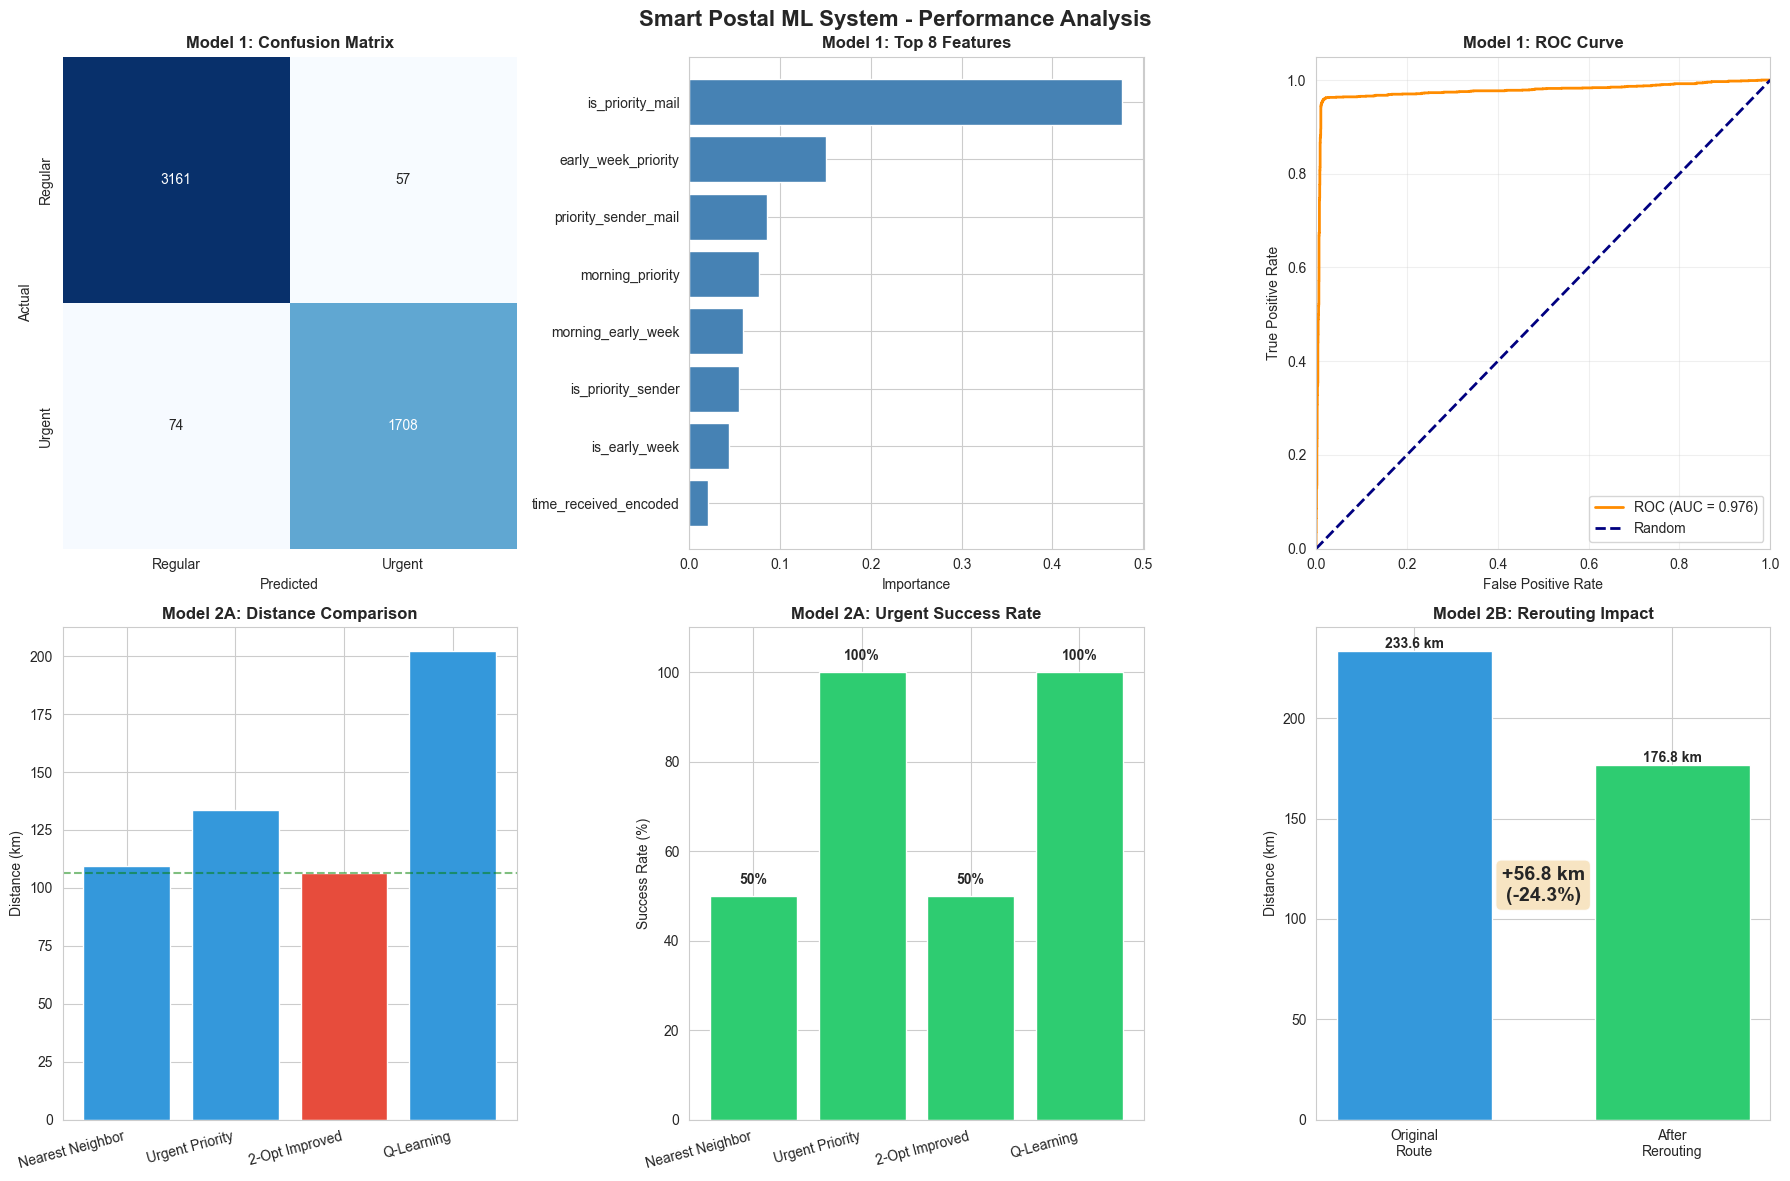

In [149]:
print("\n" + "=" * 80)
print("📊 GENERATING VISUALIZATIONS")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Smart Postal ML System - Performance Analysis', 
             fontsize=16, fontweight='bold')

# 1. Confusion Matrix
cm = priority_results['confusion_matrix']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False)
axes[0, 0].set_title('Model 1: Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xticklabels(['Regular', 'Urgent'])
axes[0, 0].set_yticklabels(['Regular', 'Urgent'])

# 2. Feature Importance
top_features = priority_results['feature_importance'].head(8)
axes[0, 1].barh(top_features['feature'], top_features['importance'], color='steelblue')
axes[0, 1].set_title('Model 1: Top 8 Features', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Importance')
axes[0, 1].invert_yaxis()

# 3. ROC Curve
fpr, tpr, _ = roc_curve(priority_results['y_test'], 
                        priority_results['y_pred_proba'][:, 1])
axes[0, 2].plot(fpr, tpr, color='darkorange', lw=2, 
               label=f'ROC (AUC = {priority_results["metrics"]["roc_auc"]:.3f})')
axes[0, 2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[0, 2].set_xlim([0.0, 1.0])
axes[0, 2].set_ylim([0.0, 1.05])
axes[0, 2].set_xlabel('False Positive Rate')
axes[0, 2].set_ylabel('True Positive Rate')
axes[0, 2].set_title('Model 1: ROC Curve', fontsize=12, fontweight='bold')
axes[0, 2].legend(loc="lower right")
axes[0, 2].grid(alpha=0.3)

# 4. Distance Comparison
methods = []
distances = []
for method, result in optimization_results['results'].items():
    methods.append(result['method'])
    distances.append(result['total_distance_km'])

colors = ['#e74c3c' if m == optimization_results['best_result']['method'] 
          else '#3498db' for m in methods]
axes[1, 0].bar(range(len(methods)), distances, color=colors)
axes[1, 0].set_title('Model 2A: Distance Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Distance (km)')
axes[1, 0].set_xticks(range(len(methods)))
axes[1, 0].set_xticklabels(methods, rotation=15, ha='right')
axes[1, 0].axhline(y=min(distances), color='green', linestyle='--', alpha=0.5)

# 5. Urgent Success Rate
urgent_success = []
for method, result in optimization_results['results'].items():
    success_rate = (result['urgent_on_time'] / total_urgent * 100) if total_urgent > 0 else 0
    urgent_success.append(success_rate)

axes[1, 1].bar(range(len(methods)), urgent_success, color='#2ecc71')
axes[1, 1].set_title('Model 2A: Urgent Success Rate', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Success Rate (%)')
axes[1, 1].set_ylim(0, 110)
axes[1, 1].set_xticks(range(len(methods)))
axes[1, 1].set_xticklabels(methods, rotation=15, ha='right')

for i, v in enumerate(urgent_success):
    axes[1, 1].text(i, v + 2, f'{v:.0f}%', ha='center', va='bottom', fontweight='bold')

# 6. Rerouting Impact
categories = ['Original\nRoute', 'After\nRerouting']
distances_reroute = [
    rerouting_result['original_route']['distance_km'],
    rerouting_result['new_route']['distance_km']
]

colors_reroute = ['#3498db', '#2ecc71']
bars = axes[1, 2].bar(categories, distances_reroute, color=colors_reroute, width=0.6)
axes[1, 2].set_title('Model 2B: Rerouting Impact', fontsize=12, fontweight='bold')
axes[1, 2].set_ylabel('Distance (km)')

for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1, 2].text(bar.get_x() + bar.get_width()/2., height,
                   f'{distances_reroute[i]:.1f} km',
                   ha='center', va='bottom', fontweight='bold')

change = rerouting_result['improvement']['distance_saved_km']
change_pct = rerouting_result['improvement']['distance_change_pct']
axes[1, 2].text(0.5, max(distances_reroute) * 0.5, 
               f'{change:+.1f} km\n({change_pct:+.1f}%)',
               ha='center', va='center', fontsize=14, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('smart_postal_ml_evaluation.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualization saved: smart_postal_ml_evaluation.png")
plt.show()

In [150]:
print("\n" + "=" * 80)
print("💾 SAVING MODELS")
print("=" * 80)

# Save Model 1
priority_model.save_model('model1_priority_classifier.pkl')
df_priority.to_csv('training_data_priority.csv', index=False)

print("\n✅ Models saved successfully:")
print("   • model1_priority_classifier.pkl")
print("   • training_data_priority.csv")
print("   • smart_postal_ml_evaluation.png")


💾 SAVING MODELS
✅ Model 1 saved to model1_priority_classifier.pkl

✅ Models saved successfully:
   • model1_priority_classifier.pkl
   • training_data_priority.csv
   • smart_postal_ml_evaluation.png


In [151]:
print("\n" + "=" * 80)
print("✅ SYSTEM TRAINING COMPLETE")
print("=" * 80)

print(f"""
╔════════════════════════════════════════════════════════════════╗
║          SMART POSTAL ML SYSTEM - FINAL SUMMARY                ║
╚════════════════════════════════════════════════════════════════╝

MODEL 1: PRIORITY CLASSIFIER
────────────────────────────
- Algorithm: XGBoost
- Accuracy: {priority_results['metrics']['accuracy']:.1%}
- Recall (Urgent): {priority_results['metrics']['recall']:.1%} {'✅' if priority_results['metrics']['recall'] >= 0.95 else '⚠️'}
- Precision: {priority_results['metrics']['precision']:.1%}
- ROC-AUC: {priority_results['metrics']['roc_auc']:.3f}

MODEL 2: REROUTING MODEL
────────────────────────
Component A: Route Optimization
- Best Algorithm: {optimization_results['best_method']}
- Best Distance: {optimization_results['best_result']['total_distance_km']} km
- Improvement: {optimization_results['best_result'].get('improvement_pct', 0):+.2f}% over baseline
- Urgent Success: {optimization_results['best_result']['urgent_on_time']}/{total_urgent}

Component B: Dynamic Rerouting
- Relocations Processed: {len(batch_relocations)}
- Distance Impact: {rerouting_result['improvement']['distance_saved_km']:+.2f} km
- Time Impact: {rerouting_result['improvement']['time_saved_hours']:+.2f} hours

SYSTEM STATUS: ✅ ALL MODELS OPERATIONAL
────────────────────────────────────────
Ready for deployment and integration with production systems.
""")


✅ SYSTEM TRAINING COMPLETE

╔════════════════════════════════════════════════════════════════╗
║          SMART POSTAL ML SYSTEM - FINAL SUMMARY                ║
╚════════════════════════════════════════════════════════════════╝

MODEL 1: PRIORITY CLASSIFIER
────────────────────────────
- Algorithm: XGBoost
- Accuracy: 97.4%
- Recall (Urgent): 95.8% ✅
- Precision: 96.8%
- ROC-AUC: 0.976

MODEL 2: REROUTING MODEL
────────────────────────
Component A: Route Optimization
- Best Algorithm: 2opt
- Best Distance: 106.43 km
- Improvement: +2.57% over baseline
- Urgent Success: 1/2

Component B: Dynamic Rerouting
- Relocations Processed: 3
- Distance Impact: +56.81 km
- Time Impact: +3.58 hours

SYSTEM STATUS: ✅ ALL MODELS OPERATIONAL
────────────────────────────────────────
Ready for deployment and integration with production systems.

